# DBSCAN

In [ ]:
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

In [ ]:
X,_=make_moons(n_samples=200,noise=0.05,random_state=42)

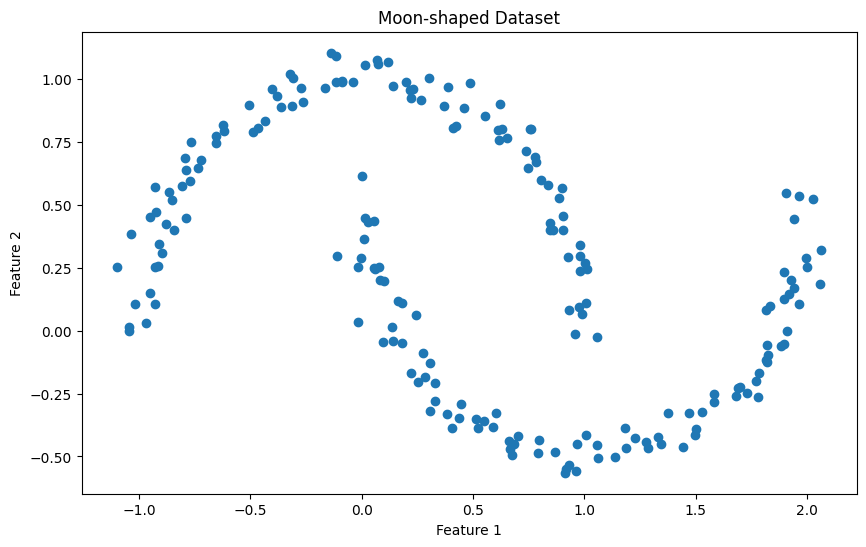

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1])
plt.title('Moon-shaped Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

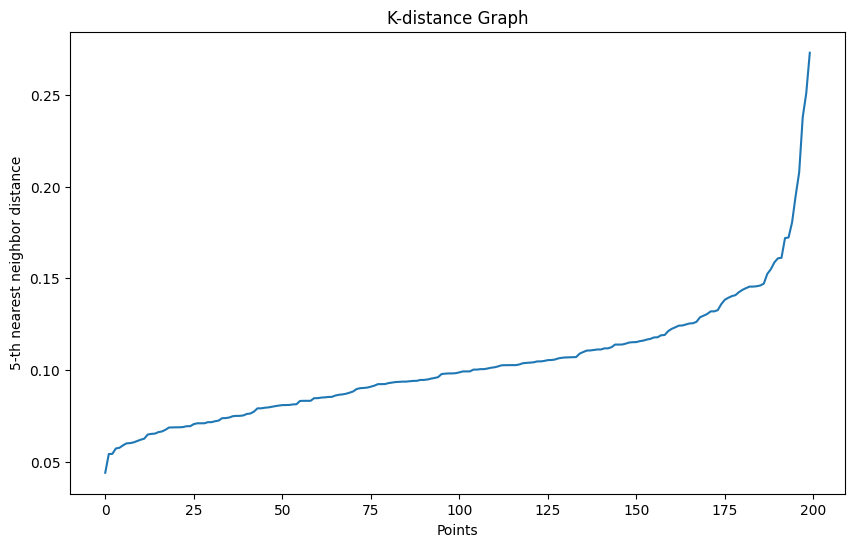

In [ ]:
def plot_k_distance_graph(X, k):
    neigh = NearestNeighbors(n_neighbors=k)
    neigh.fit(X)
    distances, _ = neigh.kneighbors(X)
    distances = np.sort(distances[:, k-1])
    plt.figure(figsize=(10, 6))
    plt.plot(distances)
    plt.xlabel('Points')
    plt.ylabel(f'{k}-th nearest neighbor distance')
    plt.title('K-distance Graph')
    plt.show()
# Plot k-distance graph
plot_k_distance_graph(X, k=5)

In [ ]:
epsilon = 0.15  # Chosen based on k-distance graph
min_samples = 5  # 2 * num_features (2D data)
dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
clusters = dbscan.fit_predict(X)

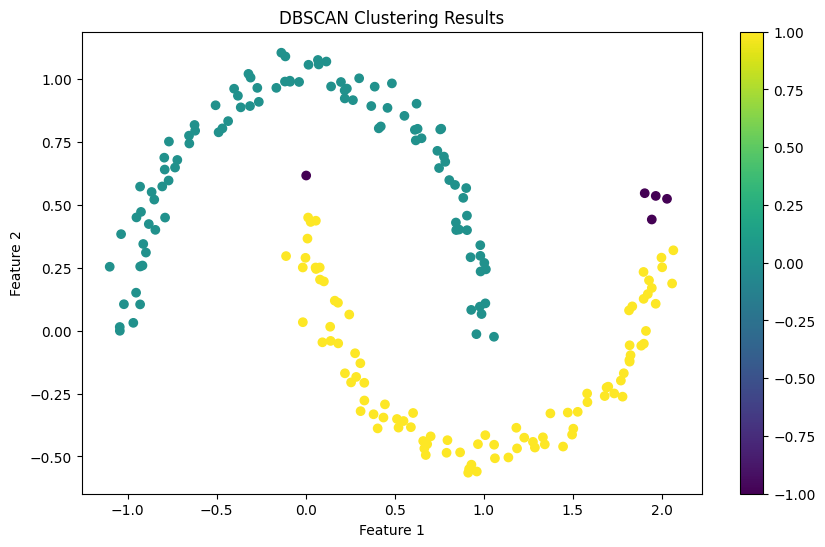

In [ ]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis')
plt.colorbar(scatter)
plt.title('DBSCAN Clustering Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [ ]:
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)
print(f'Number of clusters: {n_clusters}')
print(f'Number of noise points: {n_noise}')

Number of clusters: 2
Number of noise points: 5


Scenario: Customer Segmentation for a Retail Store
Context:
A retail store wants to understand its customers better. They have data on how much each customer spends per visit and how frequently they visit the store. The goal is to group customers into clusters (e.g., “loyal high spenders,” “occasional visitors,” etc.) using DBSCAN, which is great for finding clusters of varying shapes and identifying outliers.

In [ ]:
data = np.array([
    [5000, 50], [5200, 48], [4800, 52],
    [1500, 10], [1600, 12], [1400, 9],
    [3000, 25], [3100, 27], [2900, 24],
    [8000, 5],
    [200, 2],
])


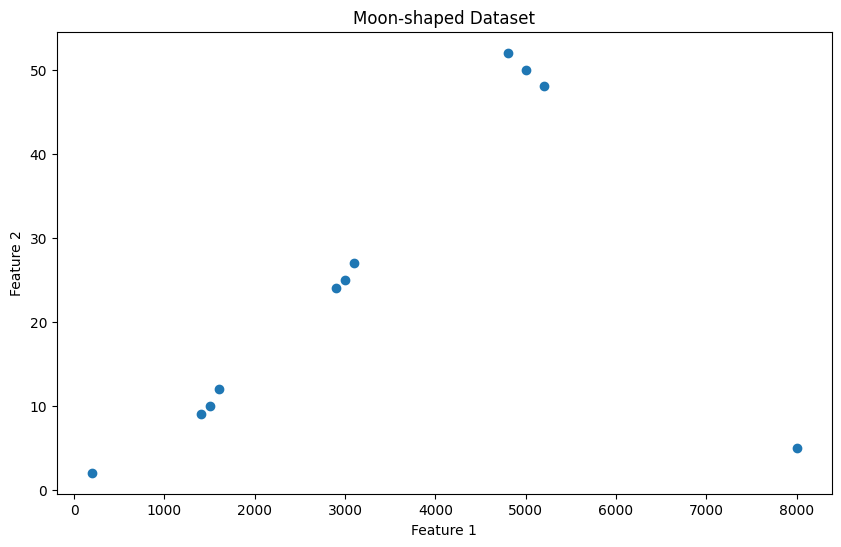

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(data[:, 0], data[:, 1])
plt.title('Moon-shaped Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

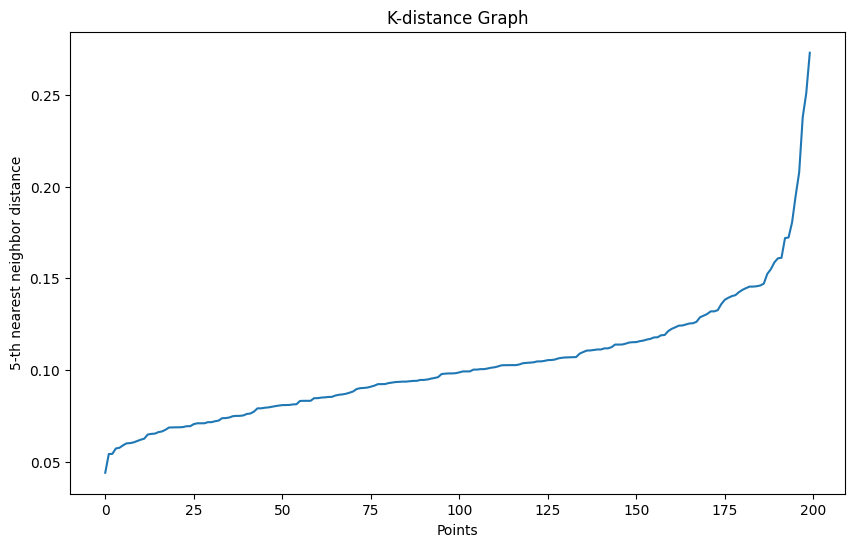

In [ ]:
def plot_k_distance_graph(X, k):
    neigh = NearestNeighbors(n_neighbors=k)
    neigh.fit(X)
    distances, _ = neigh.kneighbors(X)
    distances = np.sort(distances[:, k-1])
    plt.figure(figsize=(10, 6))
    plt.plot(distances)
    plt.xlabel('Points')
    plt.ylabel(f'{k}-th nearest neighbor distance')
    plt.title('K-distance Graph')
    plt.show()
# Plot k-distance graph
plot_k_distance_graph(X, k=5)

In [ ]:
epsilon = 0.15  # Chosen based on k-distance graph
min_samples = 5  # 2 * num_features (2D data)
dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
clusters = dbscan.fit_predict(data)

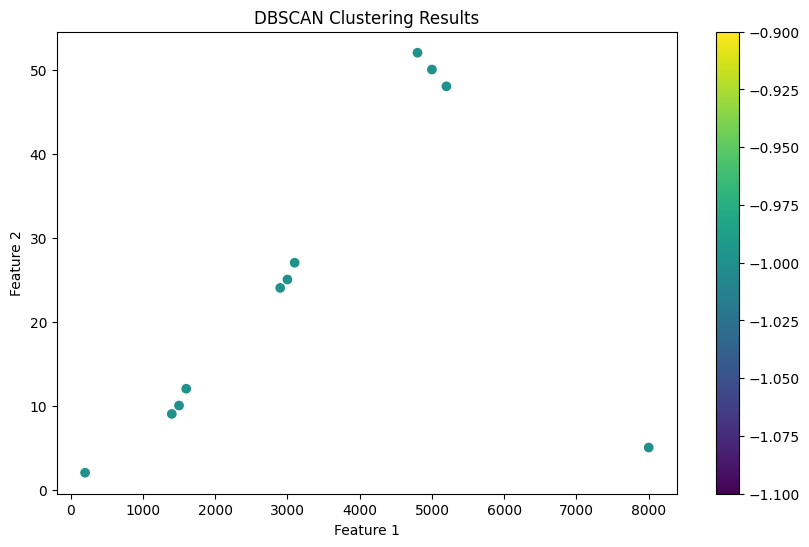

In [ ]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(data[:, 0], data[:, 1], c=clusters, cmap='viridis')
plt.colorbar(scatter)
plt.title('DBSCAN Clustering Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [ ]:
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)
print(f'Number of clusters: {n_clusters}')
print(f'Number of noise points: {n_noise}')

Number of clusters: 0
Number of noise points: 11


# Advanced CV

In [ ]:
#Fine tuning a pretrained model
# Scenario: Fine-tune ResNet-50 pretrained on ImageNet
#  to classify 5 types of plant disease from 3,000 leaf images.

In [ ]:
import torch
import torchvision
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

model = models.resnet50(weights='IMAGENET1K_V2')
for param in model.parameters():
    param.requires_grad = False
num_classes = 5
model.fc = nn.Sequential(
    nn.Dropout(0.4),

    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Linear(256, num_classes)
)
for param in model.layer4.parameters():
    param.requires_grad = True
optimizer = torch.optim.Adam([
    {'params': model.layer4.parameters(), 'lr': 1e-4},
    {'params': model.fc.parameters(), 'lr': 1e-3},
])
criterion = nn.CrossEntropyLoss()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 167MB/s]


Scenario: Fine‑tune ResNet‑50 for Music Genre Classification
Context:
A streaming service wants to automatically classify songs into genres (e.g., rock, jazz, classical, hip‑hop, electronic). They have 4,000 audio tracks labeled by genre. Instead of training from scratch, they’ll fine‑tune a ResNet‑50 pretrained on ImageNet, but adapted to work with spectrogram images of audio.

📊 Dataset
- Convert each audio track into a Mel‑spectrogram (visual representation of sound frequencies over time).
- Each spectrogram is treated like an image (RGB channels).
- Dataset: 4,000 spectrograms across 5 genres.

In [ ]:

model = models.resnet50(weights='IMAGENET1K_V2')
for param in model.parameters():
    param.requires_grad = False
num_classes = 5
model.fc = nn.Sequential(
    nn.Dropout(0.4),

    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Linear(256, num_classes)
)
for param in model.layer4.parameters():
    param.requires_grad = True
optimizer = torch.optim.Adam([
    {'params': model.layer4.parameters(), 'lr': 1e-4},
    {'params': model.fc.parameters(), 'lr': 1e-3},
])
criterion = nn.CrossEntropyLoss()